🚀 Starting Project...
✅ Data Loaded


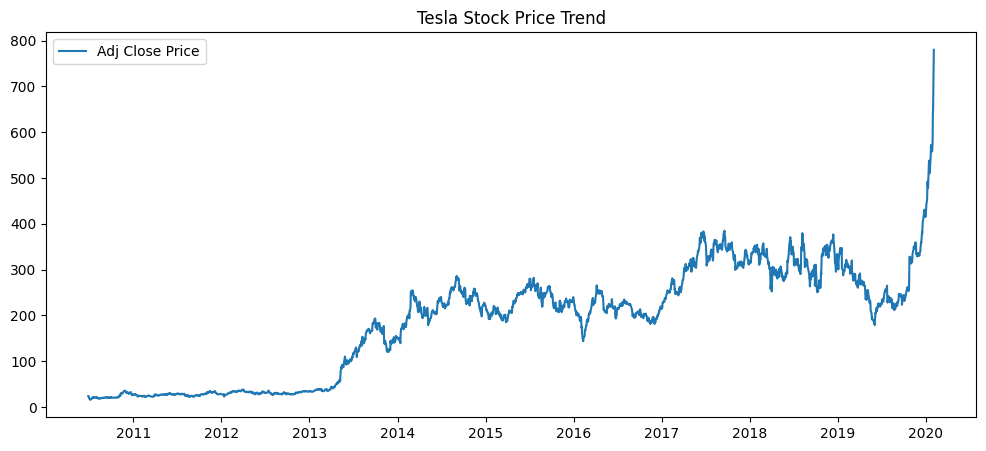

✅ Data Prepared

🔥 Training LSTM...
Epoch 1/50
59/59 [==============================] - 23s 245ms/step - loss: 0.0022 - val_loss: 0.0063
Epoch 2/50
59/59 [==============================] - 5s 76ms/step - loss: 0.0054 - val_loss: 0.0083
Epoch 3/50
59/59 [==============================] - 3s 44ms/step - loss: 0.0053 - val_loss: 0.0057
Epoch 4/50
59/59 [==============================] - 2s 37ms/step - loss: 0.0027 - val_loss: 0.0020
Epoch 5/50
59/59 [==============================] - 3s 45ms/step - loss: 5.3274e-04 - val_loss: 9.4544e-04
Epoch 6/50
59/59 [==============================] - 2s 31ms/step - loss: 2.5337e-04 - val_loss: 0.0010
Epoch 7/50
59/59 [==============================] - 2s 36ms/step - loss: 2.8161e-04 - val_loss: 0.0011
Epoch 8/50
59/59 [==============================] - 2s 39ms/step - loss: 3.0992e-04 - val_loss: 0.0012
Epoch 9/50
59/59 [==============================] - 2s 29ms/step - loss: 3.5387e-04 - val_loss: 0.0013
Epoch 10/50
59/59 [============================

In [ ]:
# =========================================
# TESLA STOCK PRICE PREDICTION 
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras import Input

print("🚀 Starting Project...")

# =========================================
# LOAD DATA
# =========================================
df = pd.read_csv('../data/TSLA.csv')

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

df = df.ffill()

print("✅ Data Loaded")

# =========================================
# VISUALIZATION
# =========================================
plt.figure(figsize=(12,5))
plt.plot(df['Adj Close'], label='Adj Close Price')
plt.title("Tesla Stock Price Trend")
plt.legend()
plt.show()

# =========================================
# FEATURE SELECTION
# =========================================
data = df[['Adj Close']]

# =========================================
# SCALING
# =========================================
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# =========================================
# CREATE DATASET
# =========================================
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step), 0])
        y.append(data[i+time_step, 0])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_dataset(scaled_data, time_step)

X = X.reshape(X.shape[0], X.shape[1], 1)

# =========================================
# TRAIN TEST SPLIT
# =========================================
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("✅ Data Prepared")

# =========================================
# LSTM MODEL (FINAL STABLE)
# =========================================
model = Sequential([
    Input(shape=(60,1)),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

print("\n🔥 Training LSTM...")

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    shuffle=False,
    verbose=1
)

print("✅ Training completed")

# =========================================
# VERIFY WEIGHTS
# =========================================
print("🔍 Number of weight arrays:", len(model.get_weights()))

# =========================================
# PREDICTIONS
# =========================================
pred = model.predict(X_test)
pred = scaler.inverse_transform(pred)

y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

# =========================================
# PLOT RESULTS
# =========================================
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label='Actual')
plt.plot(pred, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

# =========================================
# EVALUATION
# =========================================
mse = mean_squared_error(y_test_actual, pred)
print("📉 LSTM MSE:", mse)

# =========================================
# FUTURE PREDICTIONS
# =========================================
def predict_future(days):
    temp_input = list(scaled_data[-60:])
    predictions = []

    for i in range(days):
        x_input = np.array(temp_input[-60:])
        x_input = x_input.reshape(1,60,1)

        pred = model.predict(x_input, verbose=0)
        temp_input.append(pred[0])
        predictions.append(pred[0][0])

    return scaler.inverse_transform(np.array(predictions).reshape(-1,1))

print("\n🔮 Future Predictions:")
for d in [1,5,10]:
    print(f"{d} days:", predict_future(d).flatten())

# =========================================
# SAVE MODEL (FINAL CORRECT WAY)
# =========================================
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
model_dir = os.path.join(BASE_DIR, "outputs", "models")

os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, "lstm_model.h5")

# Remove old file
if os.path.exists(model_path):
    os.remove(model_path)

# Save model
model.save(model_path)

print("\n✅ MODEL SAVED:", model_path)

# =========================================
# VERIFY FILE SIZE (INFO ONLY)
# =========================================
file_size = os.path.getsize(model_path) / (1024 * 1024)
print(f"📦 Model Size: {file_size:.2f} MB")

print("✅ Notebook completed successfully")